# Filtracja bilateralna

## Konwolucja obrazu z filtrem o zadanych współczynnikach

Splot (konwolucję) obrazu wejściowego $I$ z filtrem $\psi$ dla ustalonego punktu obrazu $\mathbf{x}$ można przedstawić następująco:

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||)I(\mathbf{p})
\tag{1}
\end{equation}

gdzie:
- $\hat{I}$ jest obrazem wynikowym (przefiltrowanym),
- $W_N = \sum_y \psi(y)$ jest parametrem normalizującym współczynniki filtra $\psi$,
- $||\cdot||$ jest odległością między punktami obrazu $\mathbf{x}$ i $\mathbf{p}$ według ustalonej metryki (np. norma $L_2$). Uwaga, proszę pamiętać, że zarówno $\mathbf{x}$, jak i $\mathbf{p}$ to współrzędne przestrzenne,
- $\eta(\mathbf{x})$ jest otoczeniem punktu $\mathbf{x}$.

Funkcja $\psi$ decyduje o charakterze filtracji. Dla filtru Gaussa:

\begin{equation}
\psi(y) = G_{\delta_s}(y)
\tag{2}
\end{equation}

gdzie: $G_{\delta_s}(y)$ jest funkcją Gaussa z parametrem skali $\delta_s$.

Opisaną powyżej filtrację realizowaliśmy w ramach ćwiczenia "Przetwarzanie wstępne. Filtracja kontekstowa."

## Filtracja bilateralna

Wadą klasycznego splotu jest brak adaptacji współczynników filtra do lokalnego otoczenia $\eta(\mathbf{x})$ filtrowanego punktu $\mathbf{x}$.
Oznacza to wykorzystanie tych samych współczynników filtra $\psi$ niezależnie od tego czy otoczenie jest względnie jednorodne lub zawiera krawędzie obiektów (w tym przypadku dochodzi do "rozmywania" krawędzi).
Filtracja bilateralna uwzględnia lokalne otoczenie filtrowanego punktu, w ten sposób, że parametry filtra zmieniają się w zależności od "wyglądu" otoczenia.


Współczynniki filtra obliczane są na podstawie odległości filtrowanego punktu $\mathbf{x}$ od każdego punktu otoczenia $\mathbf{p}$ w dziedzinie przestrzennej obrazu (tak jak przy typowym filtrze np. Gaussa) oraz odległości punktów w przeciwdziedzinie obrazu (np. na podstawie różnicy w jasności pikseli dla obrazu w odcieniach szarości):

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||) \gamma(|I(\mathbf{p}) - I(\mathbf{x})|) I(\mathbf{p})
\tag{3}
\end{equation}
gdzie:
- $W_N$ jest współczynnikiem normalizującym filtr,
- $\gamma$ jest funkcją odległości w przeciwdziedzinie obrazu, np. $\gamma(y)=\exp(-\frac{y^2}{2\delta_r^2})$
- parametr $\delta_r$ jest utożsamiany z poziomem szumu w obrazie i należy go dobrać w sposób empiryczny.

Proszę chwilę zastanowić się nad powyższym równaniem, w szczególności nad funkcją $\gamma$. Proszę wyznaczyć, jaka będzie wartość funkcji dla pikseli podobnych (różnica 0, 1, 2), a skrajnie różnych (255, 200).

##  Realizacja ćwiczenia

### Wczytanie danych

1. Wczytaj dane z pliku *MR_data.mat*. W tym celu wykorzystaj funkcję `loadmat` z pakietu scipy:
        
        from scipy.io import loadmat
        mat = loadmat('MR_data.mat')

2. Wczytany plik zawiera 5 obrazów: *I_noisefree*, *I_noisy1*, *I_noisy2*, *I_noisy3* oraz *I_noisy4*. Odczytać je można w następujący sposób:
        `Input = mat[I_noisy1]`

3. Wyświetl wybrany obraz z pliku *MR_data.mat*. Zagadka - co to za obrazowanie medyczne?

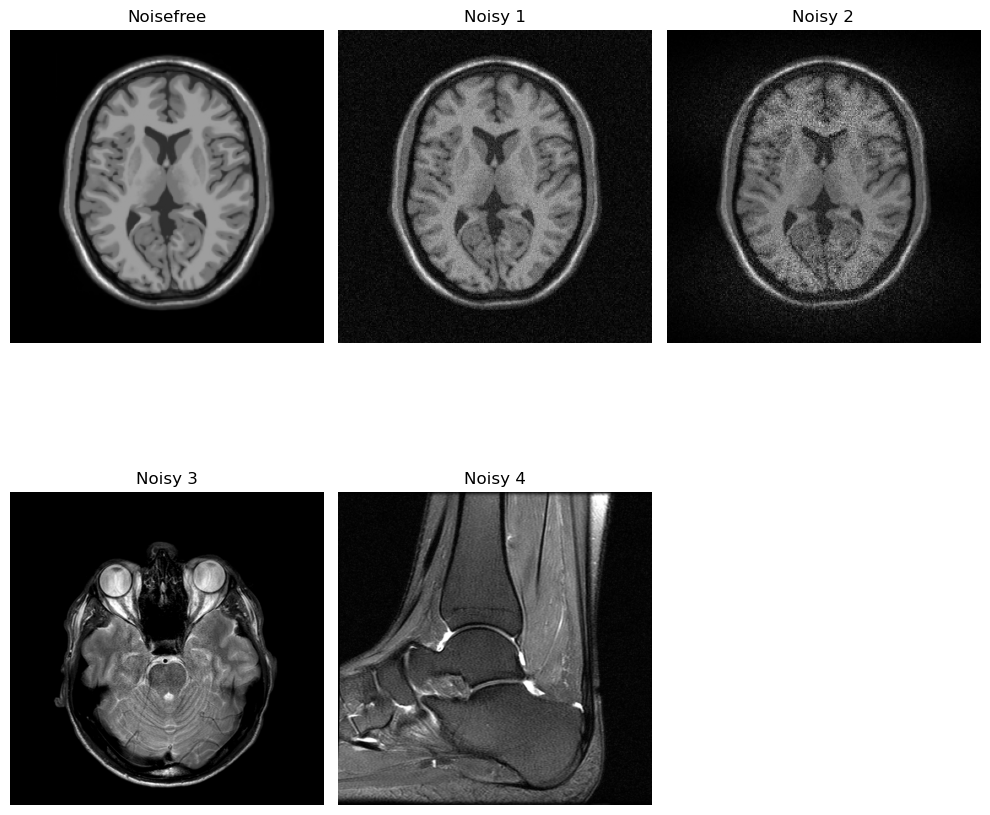

In [31]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.io import loadmat
import math
import os

if not os.path.exists("MR_data.mat") :
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/07_Bilateral/MR_data.mat --no-check-certificate

#TODO Samodzielna

mat = loadmat("MR_data.mat")

I_noisefree = mat['I_noisefree']
I_noisy1 = mat['I_noisy1']
I_noisy2 = mat['I_noisy2']
I_noisy3 = mat['I_noisy3']
I_noisy4 = mat['I_noisy4']

plt.figure(figsize=(10, 10))
plt.subplot(2, 3, 1)
plt.imshow(I_noisefree, cmap='gray')
plt.title("Noisefree")
plt.axis('off')
plt.subplot(2, 3, 2)
plt.imshow(I_noisy1, cmap='gray')
plt.title("Noisy 1")
plt.axis('off')
plt.subplot(2, 3, 3)
plt.imshow(I_noisy2, cmap='gray')
plt.title("Noisy 2")
plt.axis('off')
plt.subplot(2, 3, 4)
plt.imshow(I_noisy3, cmap='gray')
plt.title("Noisy 3")
plt.axis('off')
plt.subplot(2, 3, 5)
plt.imshow(I_noisy4, cmap='gray')
plt.title("Noisy 4")
plt.axis('off')
plt.tight_layout()
plt.show()


### "Klasyczna" konwolucja

1. Zdefiniuj parametry filtra Gaussa: rozmiar okna i wariancję $\delta_S$.
2. Oblicz współczynniki filtra na podstawie zdefiniowanych parametrów (najprościej w ramach podwójnej pętli for).
2. Sprawdź ich poprawność i zwizualizuj filtr (tak jak w ćwiczeniu pt. "Przetwarzanie wstępne. Filtracja kontekstowa.").
3. Wykonaj kopię obrazu wejściowego: `IConv = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentem tej funkcji są aktualnie przetwarzane okno i współczynniki filtra.
7. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.
8. Wyświetl wynik filtracji.
9. Porównaj wynik z obrazem oryginalnym.

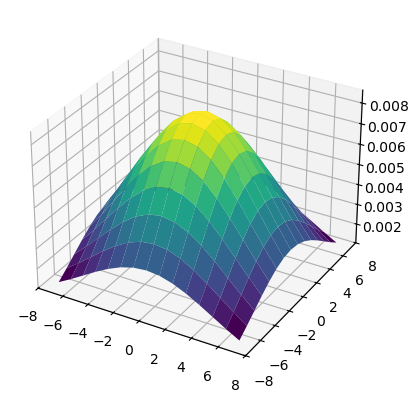

In [32]:
import numpy as np
import matplotlib.pyplot as plt


def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """Generuje znormalizowaną maskę Gaussa 2D."""
    
    # siatka współrzędnych
    size = size - 1
    ax = np.arange(-size // 2, size // 2 + 1)
    X, Y = np.meshgrid(ax, ax)

    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))

    # normalizacja
    return kernel / np.sum(kernel)


def plot_3d_surface(Z: np.ndarray):
    n = Z.shape[0]
    half = n // 2

    axis = np.arange(-half, half + 1) if n % 2 == 1 else np.arange(-half, half)
    X, Y = np.meshgrid(axis, axis)

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.plot_surface(X, Y, Z, cmap='viridis')

    plt.show()


# parametry
size = 15
sigma = 5.0

gauss = gaussian_kernel(size, sigma)
plot_3d_surface(gauss)

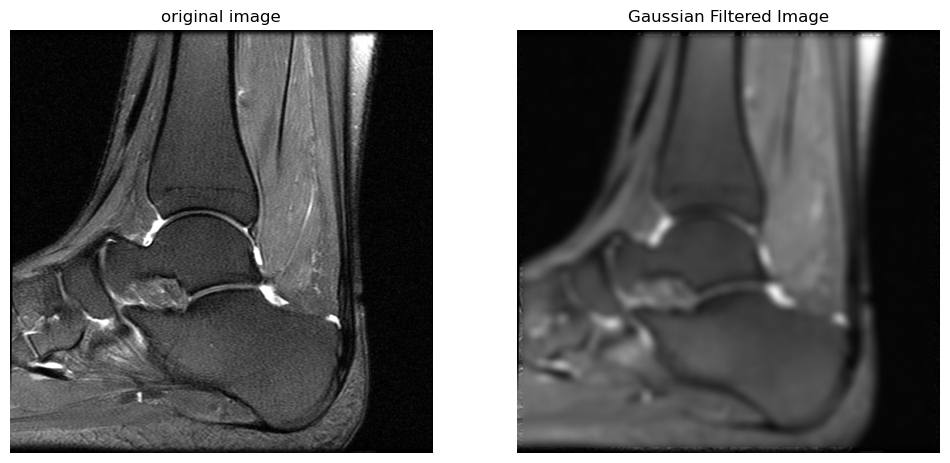

In [33]:
Input = I_noisy4
IConv = Input.copy().astype('float32')
rows,cols = Input.shape
half = size // 2

def calculate_value_of_pixel(window, kernel):
    return np.sum(window * kernel)

for i in range(half, rows - half):
    for j in range(half, cols - half):
        context = Input[i-half:i+half+1, j-half:j+half+1]
        IConv[i, j] = calculate_value_of_pixel(context, gauss)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(Input, cmap='gray')
ax[0].set_title('original image')
ax[0].axis('off')
ax[1].imshow(IConv, cmap='gray')
ax[1].set_title('Gaussian Filtered Image')
ax[1].axis('off')
plt.show()

### Filtracja bilateralna

1. Zdefiniuj dodatkowy parametr: wariancję $\delta_R$.
3. Wykonaj kopię obrazu wejściowego: `IBilateral = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentami funkcji są aktualnie przetwarzane okno, współczynniki filtra gaussowskiego (takie same jak wcześniej) i wariancja $\delta_R$.
7. Oblicz odległość w przeciwdziedzinie (dla wartości pikseli).
8. Oblicz funkcję Gaussa dla obliczonych odległości z zadanym parametrem.
9. Wykonaj normalizację obliczonych współczynników.
10. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.
11. Wyświetl wynik filtracji.
12. Porównaj wynik z obrazem oryginalnym.

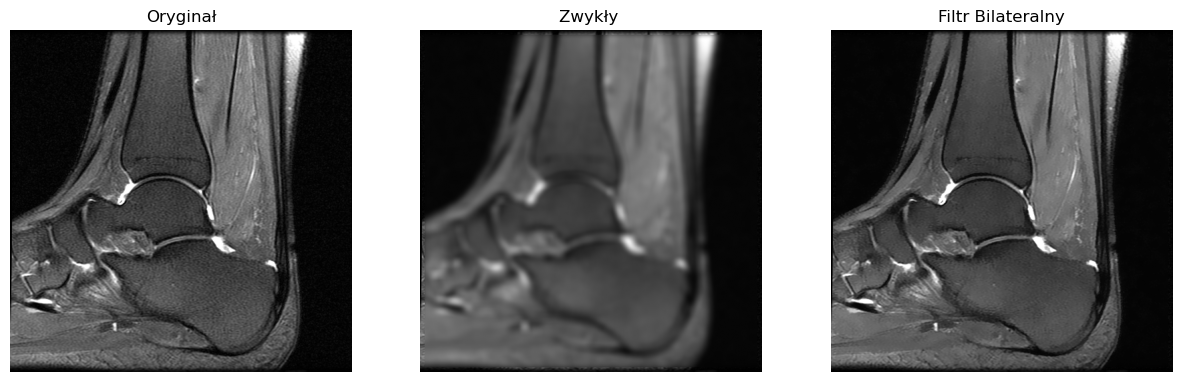

In [34]:
sigma_s = 5.0
sigma_r = 8
size  = 15
half = size // 2
gauss = gaussian_kernel(size, sigma_s)

IBilateral = Input.copy().astype('float32')
rows, cols = Input.shape

def calculate_pixel(window, spatial_kernel, sigma_r):
    center = window.shape[0] // 2
    pixel_center = window[center, center]

    diff = window.astype(float) - float(pixel_center)

    range_kernel = np.exp(-(diff ** 2) / (2 * sigma_r ** 2))

    kernel = spatial_kernel * range_kernel

    kernel /= np.sum(kernel)

    return np.sum(window * kernel)

for i in range(half, rows - half):
    for j in range(half, cols - half):
        context = Input[i - half : i + half + 1, j - half : j + half + 1]
        IBilateral[i, j] = calculate_pixel(context, gauss, sigma_r)

IBilateral = np.uint8(IBilateral)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Input, cmap='gray')
plt.title("Oryginał")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(IConv, cmap='gray')
plt.title("Zwykły ")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(IBilateral, cmap='gray')
plt.title("Filtr Bilateralny")
plt.axis('off')

plt.show()